In [1]:
import torchmetrics.segmentation
from sklearn.utils.multiclass import check_classification_targets
from torch.xpu import device

from DatasetLoading import RepairDatasetLoader
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import lightning as L

import torch
from lightning.pytorch.loggers import WandbLogger
import os

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from NerfRepresentationUtils import plot_colored_voxels
from NerfRepresentationUtils import plot_opacity_tensor
import torch.nn.functional as F

torch.set_float32_matmul_precision('medium')

from tqdm import tqdm

from torchvision.utils import save_image

from RGBAGridReconstruction import RGBAGridReconstruction
from RGBAGridReconstruction import RayManager

from copy import copy

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
dataset_loader = RepairDatasetLoader(batch_size=2, dataset_type="RGBAGridDataset",
                                         representation_folder_name="RGBAGrids", num_workers=2)


In [3]:
test_dataloader = dataset_loader.test_dataloader()

In [7]:
grid, opacity_multiplier, blank_edge_rays_o, blank_edge_rays_d, rgb_rays_o, rgb_rays_d, rgb_rays_c, piece_names = next(iter(test_dataloader))

In [5]:
grid.shape

torch.Size([2, 4, 96, 96, 96])

32


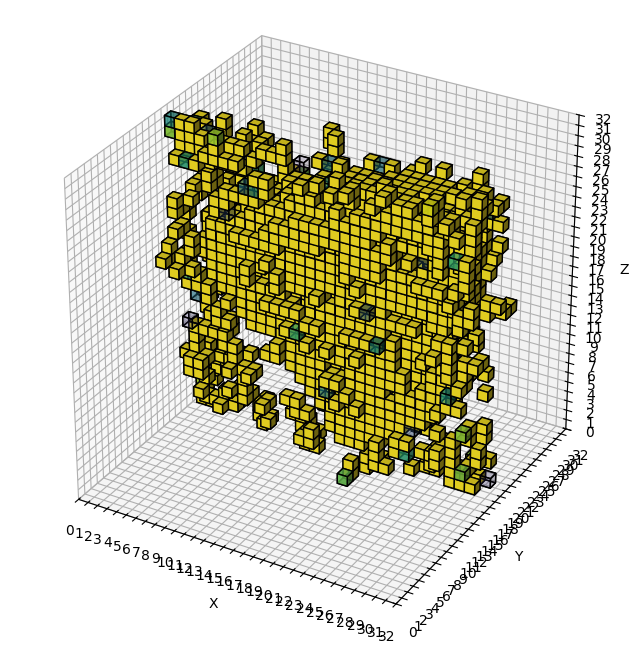

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(31, 63, None), slice(32, 64, None), slice(31, 63, None)))

In [6]:
plot_opacity_tensor(grid[0, 0])

In [7]:
density_grid = grid[:, :1]
colour_grid = grid[:, 1:]

In [8]:

def show_tensor_image(image, title=None, figsize=(10, 10), normalize=False):
    """
    Display a PyTorch image tensor using matplotlib.

    Args:
        image (torch.Tensor): Image tensor of shape (C, H, W), (H, W), or (1, H, W).
        title (str, optional): Title for the plot.
        figsize (tuple): Figure size.
        normalize (bool): If True, assumes values are in [-1, 1] and rescales to [0, 1].
    """
    if not isinstance(image, torch.Tensor):
        raise TypeError("Input must be a torch.Tensor")

    # Move to CPU, detach from computation graph
    image = image.detach().cpu()

    # Rescale if normalized to [-1, 1]
    if normalize:
        image = (image + 1) / 2

    # Clamp values to valid range
    image = image.clamp(0, 1)

    # Handle different tensor shapes
    if image.ndim == 3:
        # (C, H, W) -> (H, W, C)
        image = image.permute(1, 2, 0)

        # If grayscale with one channel, remove the channel dimension
        if image.shape[2] == 1:
            image = image.squeeze(2)
            cmap = "gray"
        else:
            cmap = None

    elif image.ndim == 2:
        cmap = "gray"

    else:
        raise ValueError(f"Unsupported image shape: {image.shape}")

    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.axis("off")


    if title:
        plt.title(title)

    plt.show()



def visualise_sample_pose(pose, density_grid, colour_grid, save_name = None, chunk=10000, device = torch.device("gpu")):
    batch_size = density_grid.shape[0]

    ray_manager = RayManager(device=device)


    sample_pose = np.load(f"SamplePoses/{pose}.npz")
    pose_rays_o = torch.tensor(sample_pose["rays_o"])
    pose_rays_d = torch.tensor(sample_pose["rays_d"])

    all_rgbs = []
    N_rays_all = pose_rays_o.shape[0]
    for chunk_idx in tqdm(range(N_rays_all // chunk + int(N_rays_all % chunk > 0))):
        rays_o = pose_rays_o[chunk_idx * chunk:(chunk_idx + 1) * chunk].to(device)
        rays_d = pose_rays_d[chunk_idx * chunk:(chunk_idx + 1) * chunk].to(device)
        xyz_sampled, z_vals, ray_valid = ray_manager.sample_ray(rays_o.unsqueeze(0).expand(batch_size, -1, -1), rays_d.unsqueeze(0).expand(batch_size, -1, -1), device=device)
        weight = ray_manager.get_opacity_weight(xyz_sampled, density_grid, ray_valid, z_vals)
        rgbs = ray_manager.get_colour(xyz_sampled, colour_grid, weight, True)
        all_rgbs.append(rgbs.cpu())
    all_rgbs = torch.cat(all_rgbs, dim=1)

    all_rgbs = all_rgbs.view(batch_size, 1080, 1920, 3).permute(0, 3, 1, 2)

    for item_id in range(batch_size):
        show_tensor_image(all_rgbs[item_id])

        if save_name is not None:
            save_image(all_rgbs, save_name)




100%|██████████| 208/208 [00:00<00:00, 221.44it/s]


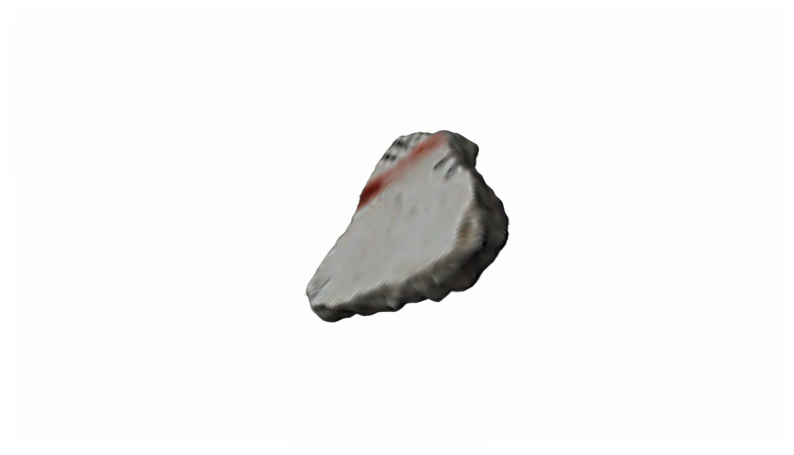

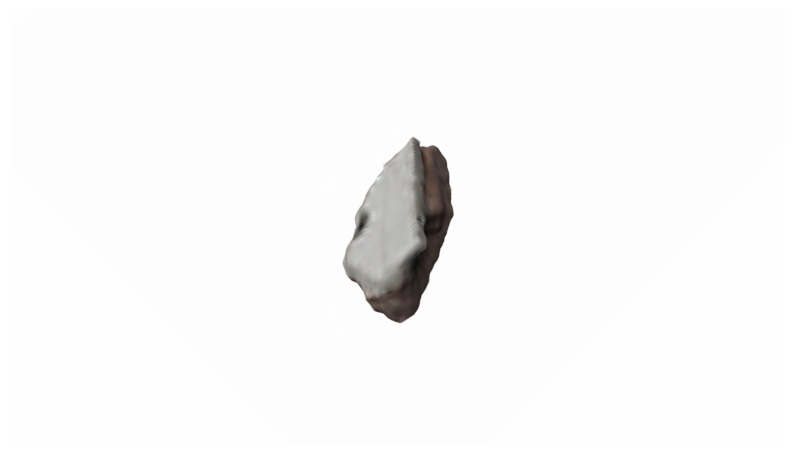

In [9]:
with torch.inference_mode():
    visualise_sample_pose("SamplePose5", density_grid.to(device), colour_grid.to(device), save_name = "testPose5gt.png", device = device)

In [5]:
lightning_model = RGBAGridReconstruction.load_from_checkpoint("RGBAReconstruction.ckpt", device=torch.device("cpu"))


/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.6.0
/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


In [11]:
with torch.inference_mode():
    lightning_model.model.to(torch.device("cpu"))
    reconstruction = lightning_model.model(grid)

In [12]:
density_reconstruction = reconstruction[:, :1]
colour_reconstruction = reconstruction[:, 1:]

100%|██████████| 208/208 [00:00<00:00, 250.94it/s]


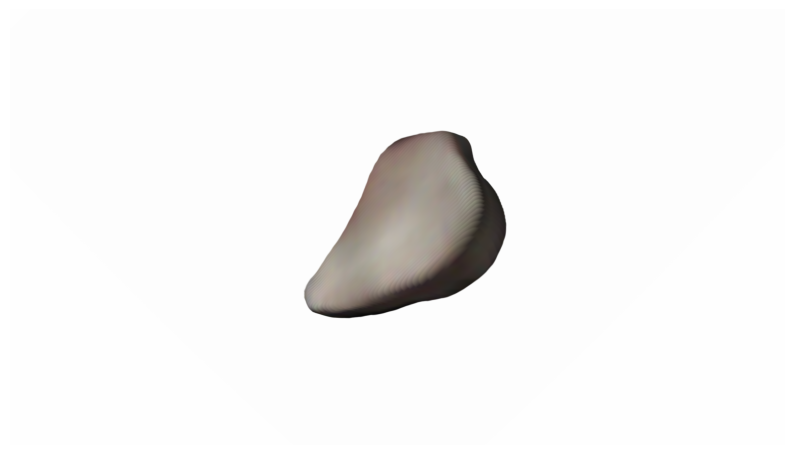

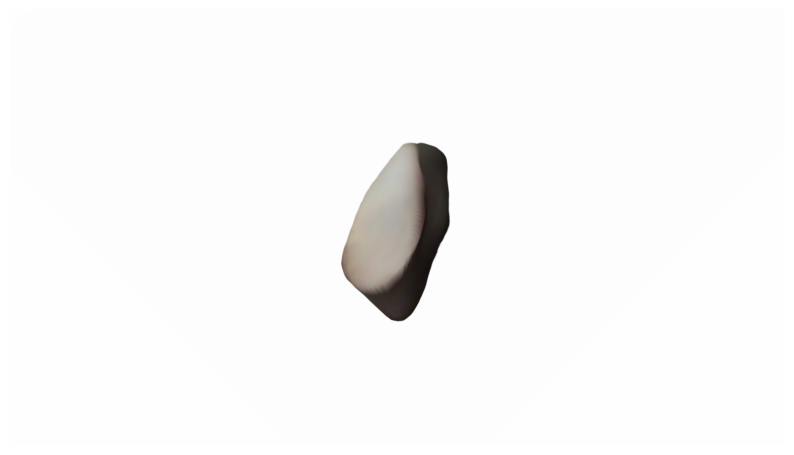

In [13]:
with torch.inference_mode():
    visualise_sample_pose("SamplePose5", density_reconstruction.to(device), colour_reconstruction.to(device), save_name = "testPose5Output.png", device =device)

In [6]:
lightning_model.test_vis_pieces

['RPf_00347',
 'RPf_00204',
 'RPf_00892',
 'RPf_00822',
 'RPf_00586',
 'RPf_00708',
 'RPf_00059',
 'RPf_00925',
 'RPf_00017',
 'RPf_00280',
 'RPf_00030',
 'RPf_00363']

In [8]:
piece_names

('RPf_00208.npz', 'RPf_00014.npz')

In [11]:
t = np.array([x in lightning_model.test_vis_pieces for x in piece_names])

In [12]:
piece_names[t]

TypeError: only integer scalar arrays can be converted to a scalar index

In [15]:
grid[np.array([True, False])].shape

torch.Size([1, 4, 96, 96, 96])

In [17]:
with torch.inference_mode():
    gt_opacity = lightning_model.density_to_opacity(density_grid, colour_reconstruction)
    reconstruction_opacity =  lightning_model.density_to_opacity(density_reconstruction, colour_reconstruction)
    print(lightning_model.get_dice_score(gt_opacity, reconstruction_opacity))


tensor(0.7605)


In [15]:
gt_opacity.shape

torch.Size([2, 1, 96, 96, 96])

22


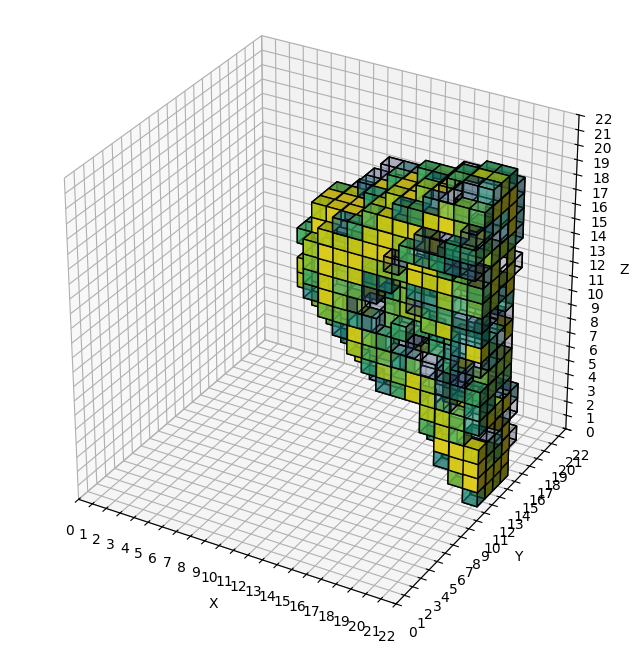

22


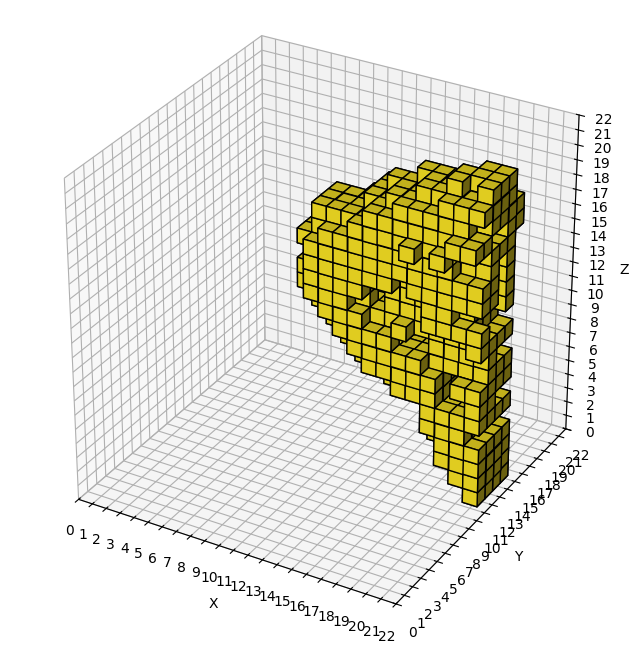

21


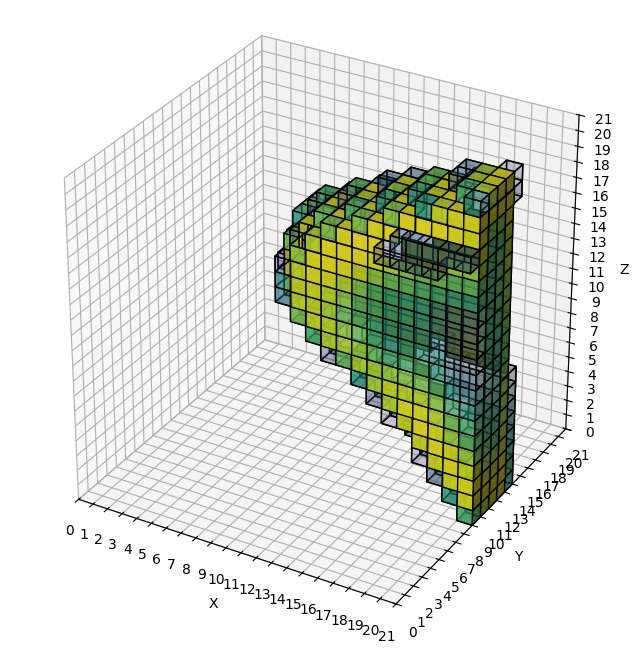

22


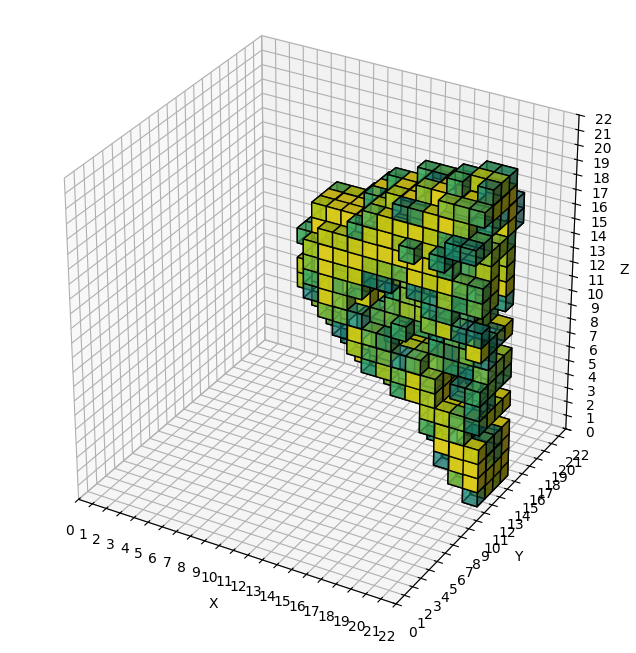

In [16]:
with torch.inference_mode():
    representation_opacity = (gt_opacity > 0.5).float()
    plot_opacity_tensor(gt_opacity[0, 0, :48])
    plot_opacity_tensor(representation_opacity[0, 0, :48])
    plot_opacity_tensor(reconstruction_opacity[0, 0, :48])
    plot_opacity_tensor(gt_opacity[0, 0, :48] * representation_opacity[0, 0, :48])


In [19]:
representation_opacity.shape

torch.Size([2, 1, 96, 96, 96])

In [3]:
checkpoints_folder = "TestCheckpoints"
model_name = "RGBAGridReconstruction"

In [31]:
model_folders = [x for x in os.listdir(checkpoints_folder) if os.path.isdir(os.path.join(checkpoints_folder, x))]
model_folder_name = model_folders[0]
model_folder_path = os.path.join(checkpoints_folder, model_folder_name)
checkpoints = [x for x in os.listdir(model_folder_path) if os.path.isfile(os.path.join(model_folder_path, x))]
renamed_checkpoints = [x.replace("=", ".") for x in checkpoints]
renamed_checkpoints = [x.replace("_", ".") for x in renamed_checkpoints]
renamed_checkpoints = [x.replace("-", ".") for x in renamed_checkpoints]
epochs = np.array([int(x.split(".")[1]) for x in renamed_checkpoints])
checkpoint_name = checkpoints[np.argmax(epochs)]
model = eval(model_name).load_from_checkpoint("InterpolatableGridReconstructionOverfitNoRays.ckpt", device=torch.device("cpu")) # CHANGE ME <---------------------------


'epoch=199-step=2400.ckpt'

In [24]:
os.listdir(checkpoints_folder)

['Test2', 'Test1']

In [18]:
def get_opacity_weight2(self, xyz_sampled, density_grid, ray_valid, z_vals):
    sigma = torch.zeros(xyz_sampled.shape[:-1], device=xyz_sampled.device)

    B, _, _, _ = xyz_sampled.shape

    # xyz_sampled: (N,3) in [-1,1]
    grid = xyz_sampled[ray_valid].view(B, -1, 1, 1, 3)
    density_grid = torch.sum(density_grid, dim=1, keepdim=True)

    sigma_feature = F.grid_sample(
        density_grid,  # (B,C,D,H,W)
        grid,
        mode="bilinear",
        align_corners=True,
    )  # (B, C, NPoints, 1, 1)
    sigma_feature = sigma_feature.squeeze()
    sigma_feature = F.softplus(sigma_feature - 10)


    sigma[ray_valid] = sigma_feature

    dists = torch.cat((z_vals[:, :, 1:] - z_vals[:, :, :-1], torch.zeros_like(z_vals[:, :, :1])), dim=-1)

    weight = self.raw2weight(sigma, dists * 25)  # 25 is the normal distance scale in the tensoRF

    return weight

def get_opacity_weight3(self, xyz_sampled, density_grid, ray_valid, z_vals):
    sigma = torch.zeros(xyz_sampled.shape[:-1], device=xyz_sampled.device)

    B, _, _, _ = xyz_sampled.shape

    # xyz_sampled: (N,3) in [-1,1]
    grid = xyz_sampled[ray_valid].view(B, 1, -1, 1, 3)
    density_grid = torch.sum(density_grid, dim=1, keepdim=True)
    density_grid = F.softplus(density_grid - 10)

    sigma_feature = F.grid_sample(
        density_grid,  # (B,C,D,H,W)
        grid,
        mode="bilinear",
        align_corners=True,
    )  # (B, C, NPoints, 1, 1)
    sigma_feature = sigma_feature.squeeze()


    sigma[ray_valid] = sigma_feature

    dists = torch.cat((z_vals[:, :, 1:] - z_vals[:, :, :-1], torch.zeros_like(z_vals[:, :, :1])), dim=-1)

    weight = self.raw2weight(sigma, dists * 25)  # 25 is the normal distance scale in the tensoRF

    return weight

def NoBasisMatRender2(features):
    shape = features.shape
    b, nchannels = shape[:2]
    extra_shape = shape[2:]
    assert nchannels == 288, "Expected 288 channels"
    features = features.view(b, 3, 96, *extra_shape)
    rgb = torch.sum(features, dim=2)
    return rgb

def get_colour2(self, xyz_sampled, colour_grid, weight, white_bg):

    B, _, _, _ = xyz_sampled.shape

    rgb = torch.zeros((*xyz_sampled.shape[:3], 3), device=xyz_sampled.device)

    app_mask = weight > 0.0001

    if app_mask.any():
        grid = xyz_sampled[app_mask].view(B, 1, -1, 1, 3)
        colour_grid = NoBasisMatRender2(colour_grid)

        app_features = F.grid_sample(
            colour_grid,      # (B,C,D,H,W)
            grid,
            mode="bilinear",
            align_corners=True,
        ) # (B, C, NPoints, 1, 1)
        valid_rgbs = app_features.view(B, colour_grid.shape[1], grid.shape[2]).permute(0, 2, 1)

        rgb[app_mask] = valid_rgbs

    acc_map = torch.sum(weight, -1)
    rgb_map = torch.sum(weight[..., None] * rgb, -2)

    if white_bg:
        rgb_map = rgb_map + (1. - acc_map[..., None])

    return rgb_map

def visualise_uninterpolated_sample_pose(pose, density_grid, colour_grid, save_name = None, chunk=10000, device = torch.device("cpu")):
    batch_size = density_grid.shape[0]

    ray_manager = RayManager(device=device)


    sample_pose = np.load(f"SamplePoses/{pose}.npz")
    pose_rays_o = torch.tensor(sample_pose["rays_o"])
    pose_rays_d = torch.tensor(sample_pose["rays_d"])

    all_rgbs = []
    N_rays_all = pose_rays_o.shape[0]
    for chunk_idx in tqdm(range(N_rays_all // chunk + int(N_rays_all % chunk > 0))):
        rays_o = pose_rays_o[chunk_idx * chunk:(chunk_idx + 1) * chunk].to(device)
        rays_d = pose_rays_d[chunk_idx * chunk:(chunk_idx + 1) * chunk].to(device)
        xyz_sampled, z_vals, ray_valid = ray_manager.sample_ray(rays_o.unsqueeze(0), rays_d.unsqueeze(0), device=device)
        weight = get_opacity_weight2(ray_manager, xyz_sampled, density_grid, ray_valid, z_vals)
        rgbs = get_colour2(ray_manager, xyz_sampled, colour_grid, weight, True)
        all_rgbs.append(rgbs.cpu())
    all_rgbs = torch.cat(all_rgbs, dim=1)

    all_rgbs = all_rgbs.view(batch_size, 1080, 1920, 3).permute(0, 3, 1, 2)

    for item_id in range(batch_size):
        show_tensor_image(all_rgbs[item_id])

        if save_name is not None:
            save_image(all_rgbs, save_name)

In [19]:
with torch.inference_mode():
    visualise_uninterpolated_sample_pose("SamplePose5", density_grid.to(device), colour_grid.to(device), save_name = "testPose5uninterp.png", device = device)

 22%|██▏       | 45/208 [00:00<00:00, 281.77it/s]


AssertionError: Expected 288 channels

In [ ]:
lightning_model.density_to_opacity()

In [24]:
density_grid.shape

torch.Size([1, 96, 96, 96, 96])

In [67]:
torch.sum(density_reconstruction, dim=1)

tensor([[[[-0.2326,  0.0381,  0.0351,  ...,  0.0299, -0.0382,  0.0298],
          [-0.1026,  0.1651,  0.1659,  ...,  0.1638,  0.0788,  0.1740],
          [-0.0747,  0.1814,  0.1819,  ...,  0.1757,  0.0729,  0.1526],
          ...,
          [-0.0847,  0.1634,  0.1601,  ...,  0.1675,  0.0714,  0.1524],
          [-0.1721,  0.0964,  0.0988,  ...,  0.1077,  0.0313,  0.1736],
          [ 0.0214,  0.0864,  0.0970,  ...,  0.1001,  0.0714,  0.0369]],

         [[-0.2671, -0.2258, -0.1941,  ..., -0.2041, -0.3114, -0.1852],
          [ 0.0671, -0.0247,  0.0250,  ...,  0.0127, -0.0917, -0.1133],
          [ 0.0744, -0.0214,  0.0360,  ...,  0.0204, -0.0966, -0.1230],
          ...,
          [ 0.0548, -0.0543, -0.0105,  ..., -0.0030, -0.1081, -0.1305],
          [-0.0710, -0.1822, -0.1360,  ..., -0.1332, -0.2081, -0.1451],
          [ 0.2283,  0.1337,  0.1641,  ...,  0.1645,  0.1595, -0.1251]],

         [[-0.2204, -0.1403, -0.0844,  ..., -0.1028, -0.2210, -0.1196],
          [ 0.0880,  0.0400,  

In [26]:
opacity_multiplier

tensor([0.4538], dtype=torch.float64)

In [16]:
density_reconstruction.shape

torch.Size([1, 96, 96, 96, 96])

In [15]:
density_reconstruction.dtype

torch.float32

In [17]:
torch.autograd.gradcheck(lightning_model.density_to_opacity, (density_reconstruction[:, :, :10, :10, :10], opacity_multiplier))

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/torch/autograd/gradcheck.py:2106: UserWarning: Input #0 requires gradient and is not a double precision floating point or complex. This check will likely fail if all the inputs are not of double precision floating point or complex. 
  _check_inputs(tupled_inputs)


True

In [18]:
lightning_model.density_to_opacity(density_reconstruction, opacity_multiplier)


tensor([[[[2.2271e-05, 2.0351e-05, 2.0388e-05,  ..., 2.0808e-05,
           2.0936e-05, 1.7980e-05],
          [2.3364e-05, 2.0407e-05, 2.0316e-05,  ..., 2.0858e-05,
           2.1059e-05, 1.8937e-05],
          [2.3040e-05, 2.0190e-05, 2.0266e-05,  ..., 2.0684e-05,
           2.1015e-05, 1.9100e-05],
          ...,
          [2.4371e-05, 2.0749e-05, 2.0454e-05,  ..., 2.0540e-05,
           2.0818e-05, 1.8696e-05],
          [2.4260e-05, 2.0666e-05, 2.0343e-05,  ..., 2.0448e-05,
           2.0513e-05, 1.8382e-05],
          [2.3542e-05, 2.0348e-05, 1.9907e-05,  ..., 2.0025e-05,
           2.0025e-05, 1.7561e-05]],

         [[2.1121e-05, 2.0487e-05, 2.0905e-05,  ..., 2.1075e-05,
           2.1124e-05, 1.8879e-05],
          [2.1513e-05, 2.0258e-05, 2.0554e-05,  ..., 2.0750e-05,
           2.1069e-05, 2.0583e-05],
          [2.1417e-05, 2.0288e-05, 2.0599e-05,  ..., 2.0702e-05,
           2.1102e-05, 2.0873e-05],
          ...,
          [2.2101e-05, 2.0532e-05, 2.0604e-05,  ..., 2.0610

46


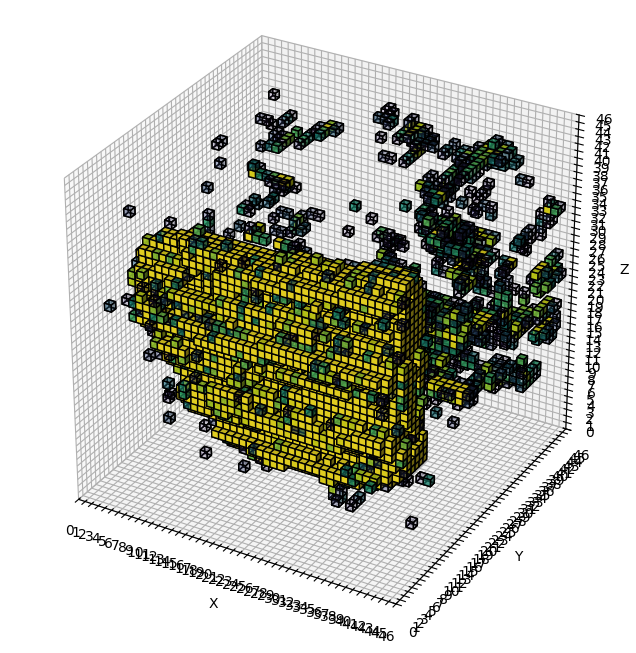

In [70]:
with torch.inference_mode():
    opacity_grid = lightning_model.density_to_opacity(density_grid, opacity_multiplier)
    plot_opacity_tensor(opacity_grid.squeeze())

In [33]:
density_grid.shape

torch.Size([1, 96, 96, 96, 96])

In [34]:
opacity_grid.shape

torch.Size([1, 96, 96, 96])

In [28]:
opacity_grid

tensor([[[2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.0601e-05, 2.0601e-05],
         [2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.0601e-05, 2.0601e-05],
         [2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.0601e-05, 2.0601e-05],
         ...,
         [2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.0601e-05, 2.0601e-05],
         [2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.0601e-05, 2.0601e-05],
         [2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.0601e-05, 2.0601e-05]],

        [[2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.0601e-05, 2.0601e-05],
         [2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.0601e-05, 2.0601e-05],
         [2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.0601e-05, 2.0601e-05],
         ...,
         [2.0601e-05, 2.0601e-05, 2.0601e-05,  ..., 2.0601e-05,
          2.060

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

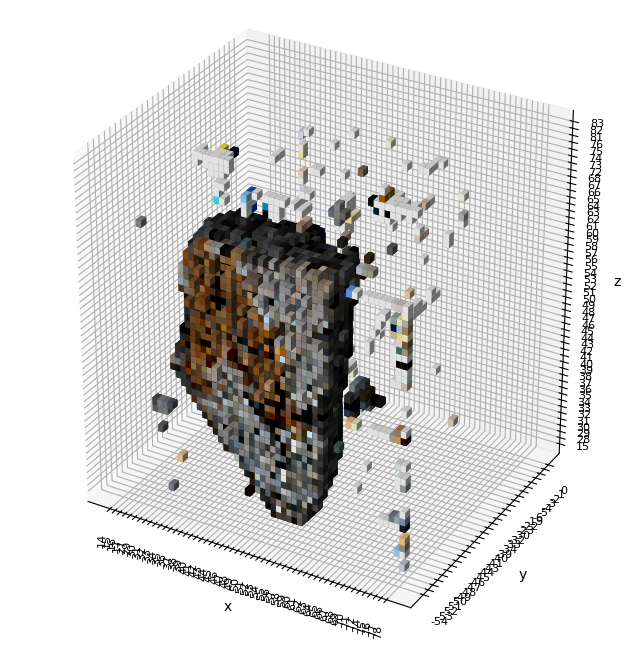

In [15]:
plot_colored_voxels(idx_tensors, colour_tensor)

In [17]:
breakable_lightning_model = InterpolatableGridReconstruction.load_from_checkpoint("InterpolatableOverfitS3LR1e3D0.ckpt", device=torch.device("cpu"))
breakable_lightning_model.RayManager = RayManager(device=torch.device("cpu"))

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.6.0
/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


In [18]:
breakable_lightning_model.log = lambda x, y: print(x,y)
breakable_lightning_model.model.forward = lambda x : x

In [19]:
breakable_lightning_model.calculate_loss(next(iter(test_dataloader)), stage="gt")

gt_l1_loss tensor(0.)
gt_density_loss tensor(0.)
gt_opacity_loss tensor(0., dtype=torch.float64)
gt_mask_colour_loss tensor(0.)
gt_mask_rgb_loss tensor(0.)
gt_focused_opacity_loss tensor(0., dtype=torch.float64)
gt_dice_loss tensor(0.9456, dtype=torch.float64)
gt_edge_loss tensor(0.0749)
gt_ray_colour_loss tensor(0.0521)
gt_final_loss tensor(0.)


tensor(0.)

In [16]:
with torch.no_grad():
    reconstructed_grid = model(representation.unsqueeze(0).to(device)).squeeze(0).cpu()

In [17]:
weights = reconstructed_grid[-1]

In [18]:
weights.shape

torch.Size([96, 96, 96])

In [19]:
r_idx_tensors = torch.where(weights > 0.3)

In [20]:
r_idx_tensors[0].shape[0]

5476

In [21]:
random_directions = F.normalize(torch.randn((r_idx_tensors[0].shape[0], 3)), p=2, dim=1)
latent = reconstructed_grid[:-1, r_idx_tensors[0], r_idx_tensors[1], r_idx_tensors[2]].T
r_colours = test_dataset.latent2representation.get_colour_from_latent(latent, random_directions).detach()


In [22]:
random_directions2 = F.normalize(torch.randn((idx_tensors[0].shape[0], 3)), p=2, dim=1)
latent2 = representation[:-1, idx_tensors[0], idx_tensors[1], idx_tensors[2]].T
r_colours2 = test_dataset.latent2representation.get_colour_from_latent(latent2, random_directions2).detach()


In [23]:
r_colours

tensor([[0.0883, 0.0142, 0.2639],
        [0.0956, 0.0445, 0.2662],
        [0.0584, 0.0318, 0.2325],
        ...,
        [0.3672, 0.3370, 0.3781],
        [0.3896, 0.3315, 0.3884],
        [0.3344, 0.2531, 0.3507]])

In [24]:
r_idx_tensors

(tensor([33, 33, 33,  ..., 63, 63, 63]),
 tensor([48, 48, 48,  ..., 51, 51, 51]),
 tensor([45, 46, 47,  ..., 63, 64, 65]))

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

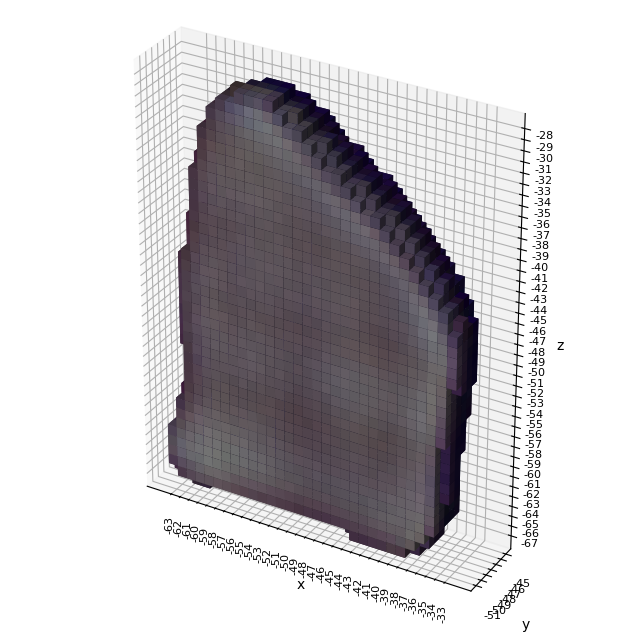

In [26]:
plot_colored_voxels(r_idx_tensors, r_colours, axis_flips=(-1, -1, -1))

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

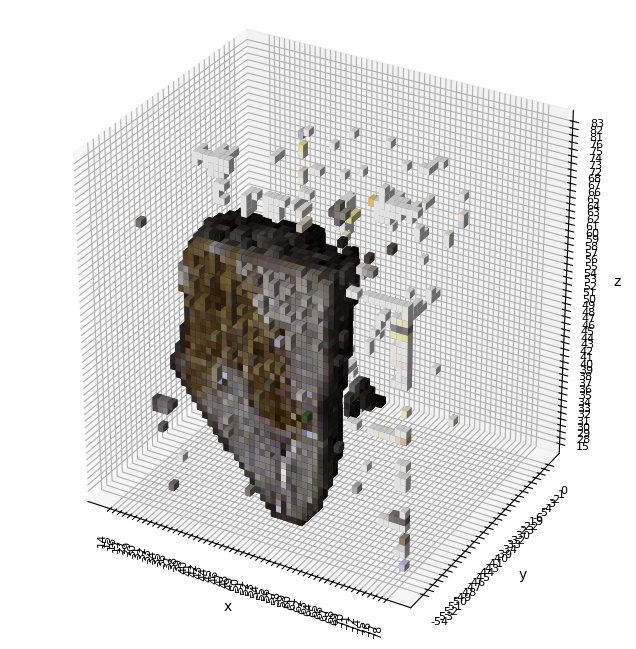

In [55]:
lot_colored_voxels(idx_tensors, r_colours2)


54


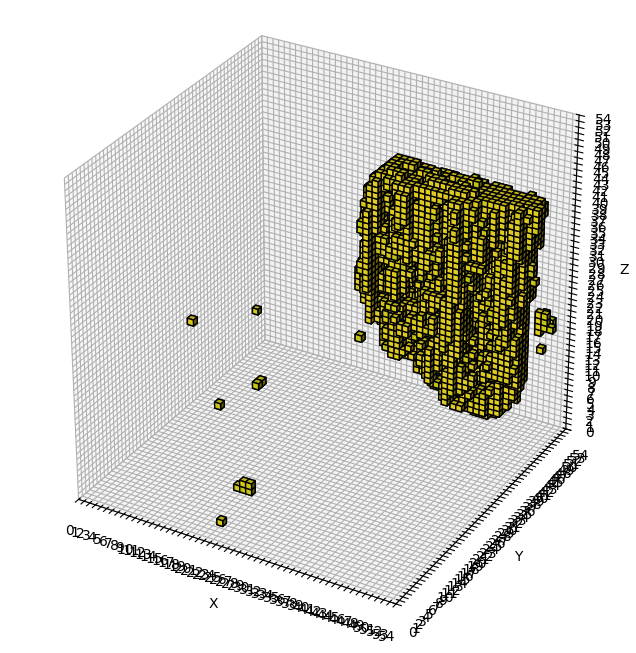

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(13, 67, None), slice(0, 54, None), slice(27, 81, None)))

In [18]:
plot_opacity_tensor(representation[-1], threshold=0.95)

69


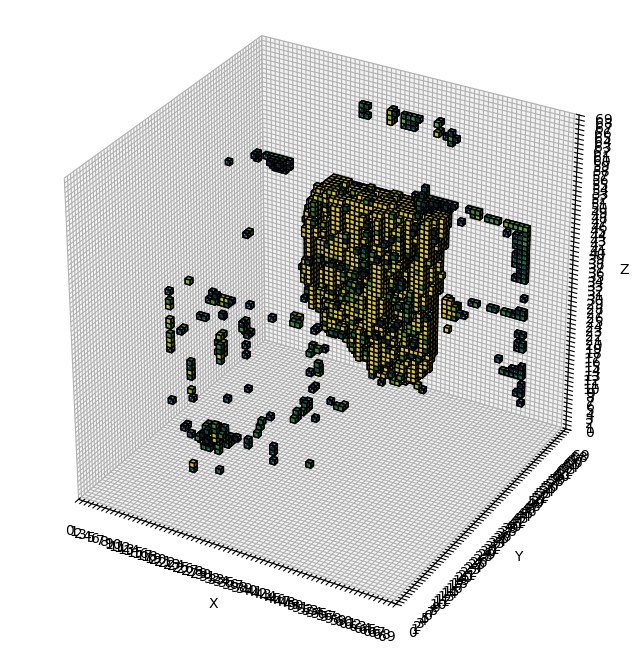

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(12, 81, None), slice(0, 69, None), slice(15, 84, None)))

In [19]:
plot_opacity_tensor(representation[-1], threshold=0.3)

40


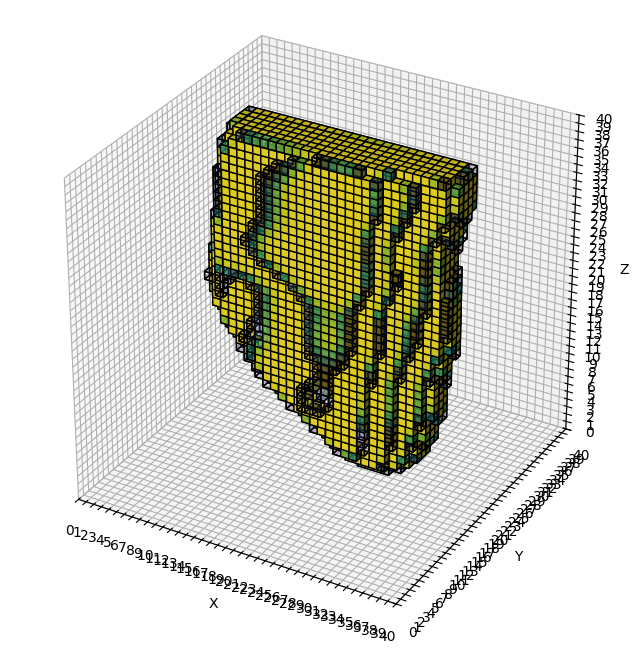

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(28, 68, None), slice(28, 68, None), slice(27, 67, None)))

In [57]:
plot_opacity_tensor(reconstructed_grid[-1], threshold=0.05)


In [21]:
import itertools

In [98]:
axis_swaps = list(itertools.permutations([0, 1, 2]))
axis_flips = [(1, 1, 1)] + list(set(itertools.permutations([1, 1, -1])))
pairs = [list(p) for p in itertools.product(range(len(axis_swaps)), range(len(axis_flips)))]
rotations = [(axis_swaps[a], axis_flips[b]) for a, b in pairs]

In [100]:
axis_swaps

[(0, 1, 2), (0, 2, 1), (1, 0, 2), (1, 2, 0), (2, 0, 1), (2, 1, 0)]

In [99]:
axis_flips

[(1, 1, 1), (1, 1, -1), (1, -1, 1), (-1, 1, 1)]

In [92]:
rotations

[(array([0, 1, 2]), array([1, 1, 1])),
 (array([0, 1, 2]), array([ 1,  1, -1])),
 (array([0, 1, 2]), array([ 1, -1,  1])),
 (array([0, 1, 2]), array([-1,  1,  1])),
 (array([0, 2, 1]), array([1, 1, 1])),
 (array([0, 2, 1]), array([ 1,  1, -1])),
 (array([0, 2, 1]), array([ 1, -1,  1])),
 (array([0, 2, 1]), array([-1,  1,  1])),
 (array([1, 0, 2]), array([1, 1, 1])),
 (array([1, 0, 2]), array([ 1,  1, -1])),
 (array([1, 0, 2]), array([ 1, -1,  1])),
 (array([1, 0, 2]), array([-1,  1,  1])),
 (array([1, 2, 0]), array([1, 1, 1])),
 (array([1, 2, 0]), array([ 1,  1, -1])),
 (array([1, 2, 0]), array([ 1, -1,  1])),
 (array([1, 2, 0]), array([-1,  1,  1])),
 (array([2, 0, 1]), array([1, 1, 1])),
 (array([2, 0, 1]), array([ 1,  1, -1])),
 (array([2, 0, 1]), array([ 1, -1,  1])),
 (array([2, 0, 1]), array([-1,  1,  1])),
 (array([2, 1, 0]), array([1, 1, 1])),
 (array([2, 1, 0]), array([ 1,  1, -1])),
 (array([2, 1, 0]), array([ 1, -1,  1])),
 (array([2, 1, 0]), array([-1,  1,  1]))]

In [93]:
len(rotations)

24

In [95]:
sum((1, -1 ,-1))

-1

In [96]:
def get_rotation_a_to_b(a, b):
    axis_swap_a = a[0]
    axis_swap_b = b[0]
    axis_flip_a = a[1]
    axis_flip_b = b[1]

    axis_swap = np.arange(3)[np.argsort(axis_swap_a)][axis_swap_b]
    axis_flip = axis_flip_a * axis_flip_b
    if np.sum(axis_flip) < -1:
        axis_flip = axis_flip * -1

    return axis_swap, axis_flip

In [97]:
test_a = rotations[7]
test_b = rotations[15]
a_to_b = get_rotation_a_to_b(test_a, test_b)
print(test_b)
print(test_a[0][a_to_b[0]])
print(test_a[1] * a_to_b[1])
a_to_b

(array([1, 2, 0]), array([-1,  1,  1]))
[1 2 0]
[-1  1  1]


(array([2, 1, 0]), array([1, 1, 1]))

In [120]:
def get_normal_category(rotations):
    swaps, flips = zip(*rotations)
    category = torch.zeros(len(rotations), 6)
    swaps = torch.tensor(swaps)

    y_flips = [flip[1] for flip in flips]
    for i, x in enumerate(y_flips):
        if x == 1:
            category[i, :3] = (swaps[i] == 1).float()
        else:
            category[i, -3:] = (swaps[i] == 1).float()

    return category

In [121]:
rotations

[((0, 1, 2), (1, 1, 1)),
 ((0, 1, 2), (1, 1, -1)),
 ((0, 1, 2), (1, -1, 1)),
 ((0, 1, 2), (-1, 1, 1)),
 ((0, 2, 1), (1, 1, 1)),
 ((0, 2, 1), (1, 1, -1)),
 ((0, 2, 1), (1, -1, 1)),
 ((0, 2, 1), (-1, 1, 1)),
 ((1, 0, 2), (1, 1, 1)),
 ((1, 0, 2), (1, 1, -1)),
 ((1, 0, 2), (1, -1, 1)),
 ((1, 0, 2), (-1, 1, 1)),
 ((1, 2, 0), (1, 1, 1)),
 ((1, 2, 0), (1, 1, -1)),
 ((1, 2, 0), (1, -1, 1)),
 ((1, 2, 0), (-1, 1, 1)),
 ((2, 0, 1), (1, 1, 1)),
 ((2, 0, 1), (1, 1, -1)),
 ((2, 0, 1), (1, -1, 1)),
 ((2, 0, 1), (-1, 1, 1)),
 ((2, 1, 0), (1, 1, 1)),
 ((2, 1, 0), (1, 1, -1)),
 ((2, 1, 0), (1, -1, 1)),
 ((2, 1, 0), (-1, 1, 1))]

In [122]:
get_normal_category(rotations)

tensor([[0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0.]])

In [7]:
with torch.no_grad():
    bottleneck_tensor = model.encoder(representation.unsqueeze(0).to(device)).squeeze(0).cpu()

In [8]:
bottleneck_tensor.shape

torch.Size([256, 25, 25, 25])

In [14]:
reconstructed_grid = reconstructed_grid.unsqueeze(0)

In [15]:
reconstructed_grid.shape

torch.Size([1, 32, 200, 200, 200])

In [16]:
reconstructed_grid_opacity = reconstructed_grid[:, -1:]

In [17]:
reconstructed_grid_opacity.shape

torch.Size([1, 1, 200, 200, 200])

In [20]:
(reconstructed_grid_opacity > 0.5) * 1

tensor([[[[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          ...,

          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          [[0, 0, 0,  ..

In [20]:
lightning_model.get_dice_loss(representation, reconstructed_grid)

tensor(nan)

In [44]:
representation = representation.unsqueeze(0)
reconstructed_grid = reconstructed_grid.unsqueeze(0)

In [45]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [46]:
reconstructed_grid.shape

torch.Size([1, 32, 200, 200, 200])

In [47]:
target = lightning_model.categorise_representation(representation)

In [48]:
pred = lightning_model.categorise_representation(reconstructed_grid)

In [49]:
reconstructed_grid.shape

torch.Size([1, 32, 200, 200, 200])

In [50]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [51]:
(representation[:, -1:] > 0.3).long().shape

torch.Size([1, 1, 200, 200, 200])

In [52]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [53]:
lightning_model.get_dice_loss(reconstructed_grid, representation)


tensor(0.)

In [54]:
pred.shape

torch.Size([1, 1, 200, 200, 200])

In [55]:
pred[:, :, :, :, 0] = 1

In [56]:
lightning_model.dice_loss_score(pred, target)

tensor(0.)

In [59]:
from torchmetrics.segmentation import DiceScore

In [68]:
dice_score = DiceScore(num_classes=2, include_background=False, input_format='index')

In [69]:
dice_score(pred, target)

tensor(0.9936)

In [71]:
dice_score(target, target)

tensor(1.)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

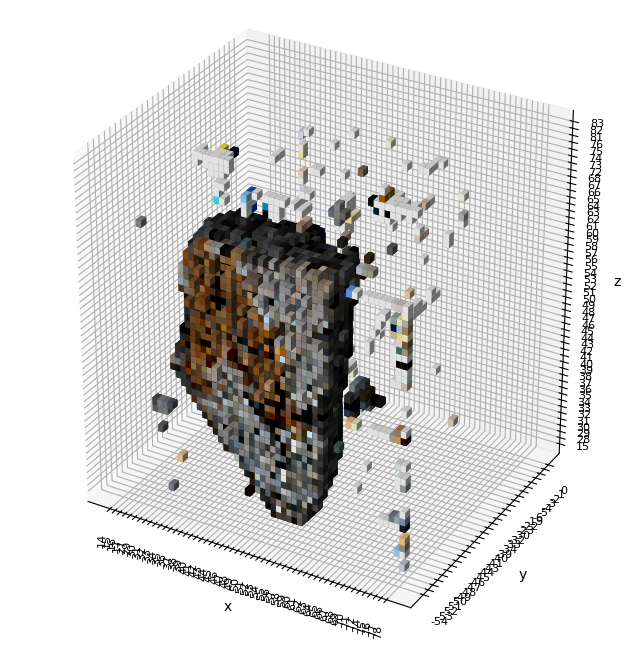

In [20]:
plot_colored_voxels(idx_tensors, colour_tensor)


In [60]:
def filter_by_cord(in_idx_tensors, in_colour_tensor, limits):
    out_idx_tensors = in_idx_tensors
    out_colour_tensor = in_colour_tensor
    for ax, (min, max) in enumerate(limits):

        new_filter = torch.logical_and(out_idx_tensors[ax] > min, out_idx_tensors[ax] < max)
        out_idx_tensors = [x[new_filter] for x in out_idx_tensors]
        out_colour_tensor = out_colour_tensor[new_filter]
    return out_idx_tensors, out_colour_tensor

In [61]:
idx_tensors[0]

tensor([14, 14, 15,  ..., 78, 78, 78], dtype=torch.int32)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

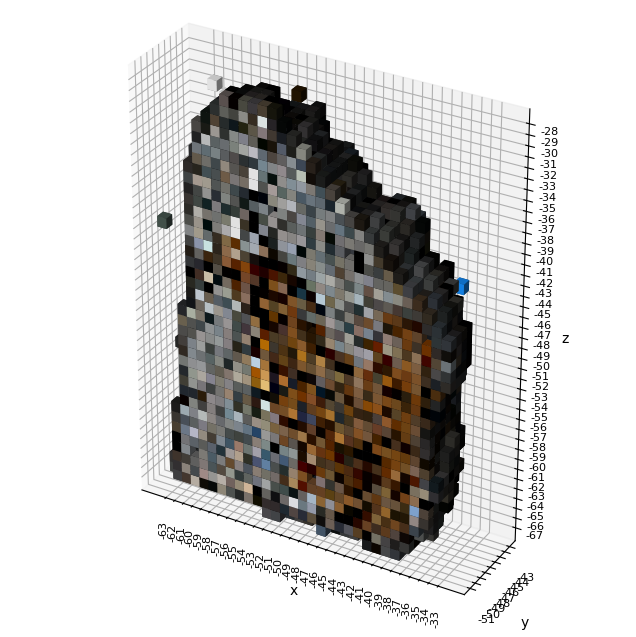

In [71]:
plot_colored_voxels(*filter_by_cord(idx_tensors, colour_tensor, [(32, 64), (40, 52), (26, 69)]), axis_flips=(-1, -1, -1))